In [1]:
# Free Body Diagram Solver
# Solves for unknown reactions using equilibrium equations
# Sum Fx = 0, Sum Fy = 0, Sum M = 0

import numpy as np
import matplotlib.pyplot as plt

# Simply supported beam example
# Beam length 10 meters
# Point load P = 500 N at x = 4 meters from left support

L = 10.0    # beam length (m)
P = 500.0   # applied load (N)
a = 4.0     # load position from left (m)

# equilibrium equations in matrix form
# [A]{x} = {b}
# unknowns: x = [Ay, By]
# equation 1: Ay + By = P          (sum Fy = 0)
# equation 2: By * L = P * a       (sum M about A = 0)

A = np.array([
    [1.0,  1.0],
    [0.0,  L  ]
])

b = np.array([P, P * a])

# solve for reactions
reactions = np.linalg.solve(A, b)

Ay = reactions[0]
By = reactions[1]

print("=== Simply Supported Beam — FBD Solver ===")
print("Beam length:     " + str(L) + " m")
print("Applied load:    " + str(P) + " N at x = " + str(a) + " m")
print("")
print("Reactions:")
print("  Ay (left):     " + str(round(Ay, 3)) + " N")
print("  By (right):    " + str(round(By, 3)) + " N")
print("")
print("Verification:")
print("  Sum Fy:        " + str(round(Ay + By - P, 6)) + " N (should be 0)")
print("  Sum M about A: " + str(round(By * L - P * a, 6)) + " N.m (should be 0)")

=== Simply Supported Beam — FBD Solver ===
Beam length:     10.0 m
Applied load:    500.0 N at x = 4.0 m

Reactions:
  Ay (left):     300.0 N
  By (right):    200.0 N

Verification:
  Sum Fy:        0.0 N (should be 0)
  Sum M about A: 0.0 N.m (should be 0)


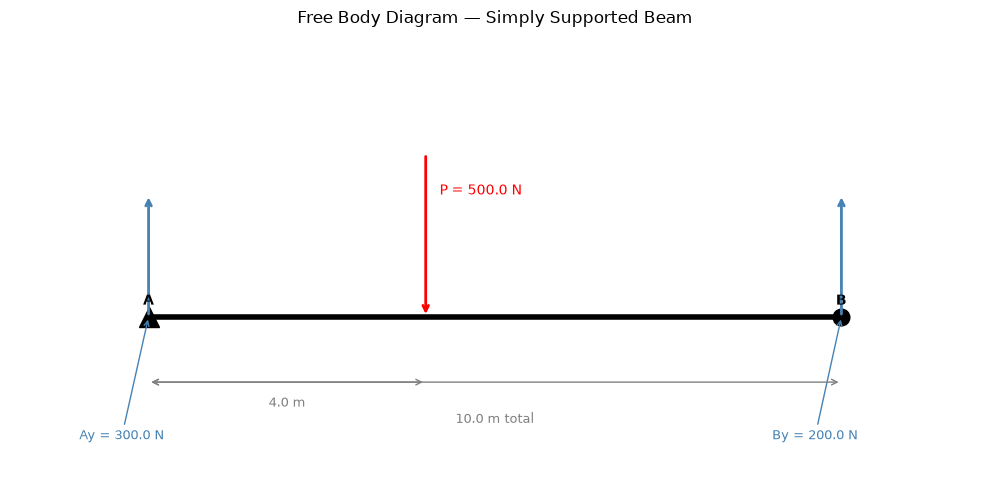

diagram saved


In [2]:
# Free Body Diagram

fig, ax = plt.subplots(figsize=(10, 5))

# beam
ax.plot([0, L], [0, 0], 'k-', linewidth=4)

# left support (pin) - triangle
ax.plot(0, 0, 'k^', markersize=15)
ax.annotate('Ay = ' + str(round(Ay, 1)) + ' N',
            xy=(0, 0), xytext=(-1, -1.5),
            fontsize=9, color='steelblue',
            arrowprops=dict(arrowstyle='->', color='steelblue'))

# right support (roller) - circle
ax.plot(L, 0, 'ko', markersize=12)
ax.annotate('By = ' + str(round(By, 1)) + ' N',
            xy=(L, 0), xytext=(L-1, -1.5),
            fontsize=9, color='steelblue',
            arrowprops=dict(arrowstyle='->', color='steelblue'))

# applied load arrow
ax.annotate('', xy=(a, 0), xytext=(a, 2),
            arrowprops=dict(arrowstyle='->', color='red', lw=2))
ax.text(a+0.2, 1.5, 'P = ' + str(P) + ' N', color='red', fontsize=10)

# reaction arrows
ax.annotate('', xy=(0, 1.5), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='steelblue', lw=2))
ax.annotate('', xy=(L, 1.5), xytext=(L, 0),
            arrowprops=dict(arrowstyle='->', color='steelblue', lw=2))

# dimensions
ax.annotate('', xy=(a, -0.8), xytext=(0, -0.8),
            arrowprops=dict(arrowstyle='<->', color='gray'))
ax.text(a/2, -1.1, str(a) + ' m', ha='center', color='gray', fontsize=9)
ax.annotate('', xy=(L, -0.8), xytext=(0, -0.8),
            arrowprops=dict(arrowstyle='<->', color='gray'))
ax.text(L/2, -1.3, str(L) + ' m total', ha='center', color='gray', fontsize=9)

# labels
ax.text(0, 0.15, 'A', fontsize=10, ha='center', fontweight='bold')
ax.text(L, 0.15, 'B', fontsize=10, ha='center', fontweight='bold')

ax.set_xlim(-2, L+2)
ax.set_ylim(-2, 3.5)
ax.axis('off')
ax.set_title('Free Body Diagram — Simply Supported Beam')
plt.tight_layout()
plt.savefig('fbd_diagram.png')
plt.show()
print("diagram saved")